In [1]:
import os 
from glob import glob 


import torch 
from monai.transforms import (
    Compose,
    LoadImaged,
    ToTensord,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityRanged,
    CropForegroundd,
    Resized,
)

from monai.data import Dataset, DataLoader
from monai.utils import first
import matplotlib.pyplot as plt
from monai.transforms import RandSpatialCropd


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = "/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT"
train_images = sorted(glob(os.path.join(data_dir, "TRAINING", "**", "*.nii")))
train_labels = sorted(glob(os.path.join(data_dir, "TRAINING", "**", "*wmh.nii")))


val_images = sorted(glob(os.path.join(data_dir, "VALIDATION", "**", "*.nii")))
val_labels = sorted(glob(os.path.join(data_dir, "VALIDATION", "**", "*wmh.nii")))


train_files = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
val_files = [{"image": image_name, "label": label_name} for image_name, label_name in zip(val_images, val_labels)]

In [3]:
print(train_files)
print(val_files)

[{'image': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_01/FLAIR.nii', 'label': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_01/wmh.nii'}, {'image': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_01/wmh.nii', 'label': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_02/wmh.nii'}, {'image': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_02/FLAIR.nii', 'label': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_03/wmh.nii'}, {'image': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_02/wmh.nii', 'label': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_04/wmh.nii'}, {'image': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_03/FLAIR.nii', 'label': '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING/UTR_05/wmh.nii'}, {'image': '/Users/alert/Downloads/WMH_EXPER

In [4]:
import torch
import matplotlib.pyplot as plt
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, 
    NormalizeIntensityd, CropForegroundd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, RandGaussianNoised, ToTensord
)
from monai.data import Dataset, DataLoader, decollate_batch
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.utils import first

# 1. ENHANCED PREPROCESSING & AUGMENTATION
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    # 1mm isotropic resolution is standard for WMH
    Spacingd(
        keys=["image", "label"], 
        pixdim=(1.0, 1.0, 1.0), 
        mode=("bilinear", "nearest")
    ),
    # MRI specific normalization (Z-score)
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    
    # CRITICAL: Ensures 3 out of 4 patches contain a lesion (label=1)
    # This prevents the model from only learning to predict "background"
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=3,
        neg=1,
        num_samples=4, # Create 4 patches per volume
        image_key="image",
        image_threshold=0,
        allow_smaller=True
    ),
    


# This will take a 96x96x96 chunk from any size image
    RandSpatialCropd(
        keys=["image", "label"], 
        roi_size=(96, 96, 96), 
        random_center=True, 
        random_size=False
    ),
    # Data Augmentation to prevent overfitting
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    RandGaussianNoised(keys="image", prob=0.1),
    ToTensord(keys=["image", "label"]),
    Resized(keys=["image", "label"], spatial_size=(96, 96, 96))
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ToTensord(keys=["image", "label"]),
])

# 2. DATA LOADERS
# Using CacheDataset is highly recommended if you have enough RAM
train_ds = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)

val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=0)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/monai/networks/nets/unet.py:131: UserWarning: `len(strides) > len(channels) - 1`, the last 1 values of strides will not be used.
  warnings.warn(f"`len(strides) > len(channels) - 1`, the last {delta} values of strides will not be used.")


Patch shape: torch.Size([4, 1, 96, 96, 96])


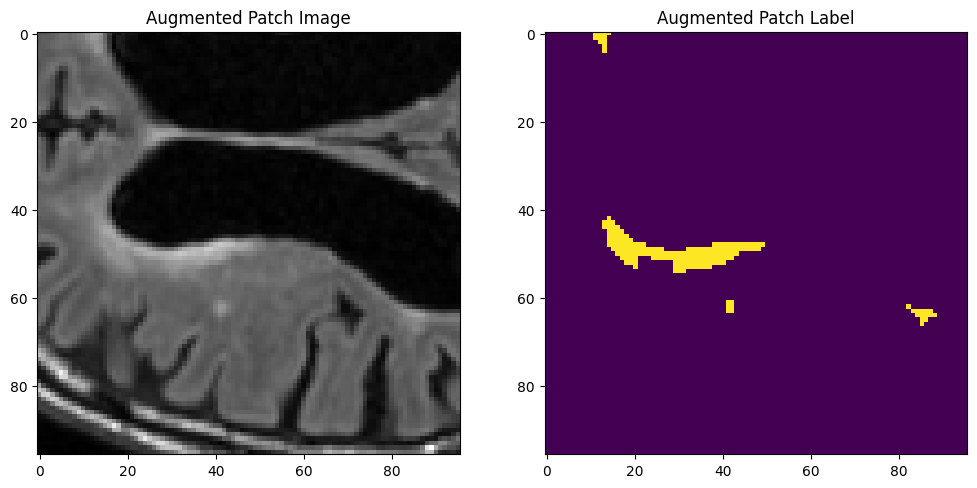

In [5]:


from monai.losses import DiceCELoss
device = torch.device("cpu")


model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1, # Binary segmentation
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2, 2),
    num_res_units=1,
).to(device)

model = model.to(device)

# DiceLoss is much better than CrossEntropy for small lesions
loss_function = DiceCELoss(sigmoid=True, squared_pred=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)

# 4. VISUALIZATION CHECK
check_ds = Dataset(data=train_files, transform=train_transforms)
check_loader = DataLoader(check_ds, batch_size=1)
check_data = first(check_loader)

print(f"Patch shape: {check_data['image'].shape}") 

plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Augmented Patch Image")
plt.imshow(check_data["image"][0, 0, :, :, 48], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Augmented Patch Label")
plt.imshow(check_data["label"][0, 0, :, :, 48])
plt.show()

In [9]:
import torch
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.utils import set_determinism

# 1. SETUP
set_determinism(seed=42)
max_epochs = 100
val_interval = 2 # Validate every 2 epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Metric and Post-processing
# We convert sigmoid outputs to discrete 0 or 1 for the Dice score
dice_metric = DiceMetric(include_background=False, reduction="mean")
post_trans = AsDiscrete(threshold=0.5)

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

# 2. TRAINING LOOP
for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        if step % 10 == 0:
            print(f"{step}/{len(train_ds) // train_loader.batch_size}, train_loss: {loss.item():.4f}")
            
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    # 3. VALIDATION LOOP
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                
                # SLIDING WINDOW INFERENCE
                # Use the same roi_size as your training patches (96, 96, 96)
                roi_size = (96, 96, 96)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
                
                # Post-process for Metric Calculation
                val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
                val_labels = decollate_batch(val_labels)
                
                dice_metric(y_pred=val_outputs, y=val_labels)

            # Aggregate and reset metric
            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            metric_values.append(metric)
            
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_wmh_unet.pth")
                print("Saved new best model!")
                
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}"
            )

print(f"Training completed. Best dice: {best_metric:.4f} at epoch: {best_metric_epoch}")

----------
epoch 1/100
epoch 1 average loss: 1.7278
----------
epoch 2/100
epoch 2 average loss: 1.7180
Saved new best model!
current epoch: 2 current mean dice: 0.0635
best mean dice: 0.0635 at epoch: 2
----------
epoch 3/100
epoch 3 average loss: 1.7194
----------
epoch 4/100
epoch 4 average loss: 1.7195
current epoch: 4 current mean dice: 0.0616
best mean dice: 0.0635 at epoch: 2
----------
epoch 5/100
epoch 5 average loss: 1.7188
----------
epoch 6/100
epoch 6 average loss: 1.7196
current epoch: 6 current mean dice: 0.0612
best mean dice: 0.0635 at epoch: 2
----------
epoch 7/100
epoch 7 average loss: 1.7161
----------
epoch 8/100
epoch 8 average loss: 1.7102
current epoch: 8 current mean dice: 0.0605
best mean dice: 0.0635 at epoch: 2
----------
epoch 9/100


KeyboardInterrupt: 

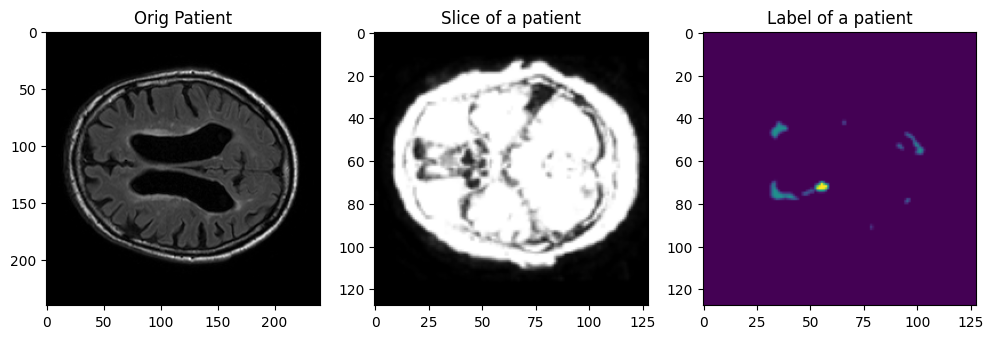

In [ ]:
orig_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=['image', 'label']),
        ToTensord(keys=['image', 'label'])
    ]
)


train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2)),
        ScaleIntensityRanged(keys="image", a_min=-200, a_max=200, b_min=0.0, b_max=1.0, clip=True),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        Resized(keys=["image", "label"], spatial_size=[128, 128, 128]),
        ToTensord(keys=["image", "label"]),
    ]
)


val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2)),
        ScaleIntensityRanged(keys="image", a_min=-200, a_max=200, b_min=0.0, b_max=1.0, clip=True),
        ToTensord(keys=["image", "label"]),
    ]
)


orig_ds = Dataset(data=train_files, transform=orig_transforms)
orig_loader = DataLoader(orig_ds, batch_size=1)


train_ds = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=1)

val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1)



test_patient = first(train_loader)
orig_patient = first(orig_loader)


plt.figure('test', (12, 6))

plt.subplot(1, 3, 1)
plt.title("Orig Patient")

plt.imshow(orig_patient['image'][0,0, :, : , 30], cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Slice of a patient")

plt.imshow(test_patient['image'][0,0,:,:,30], cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Label of a patient")
plt.imshow(test_patient['label'][0,0,:,:,60])

plt.show()



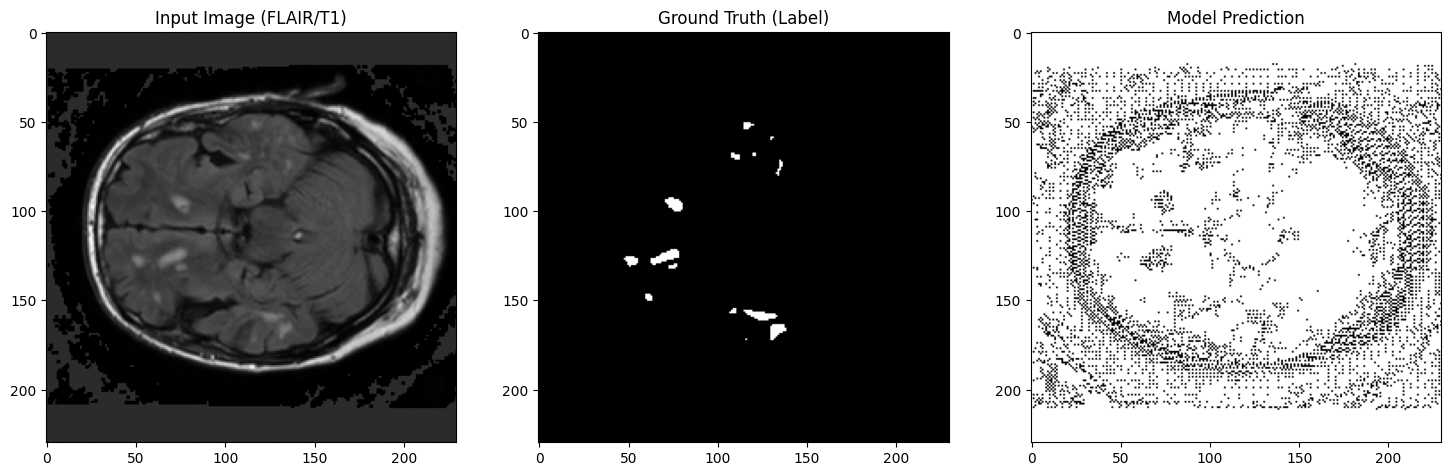

In [7]:
import torch
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference

# 1. Load the best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("best_wmh_unet.pth"))
model.eval()

# 2. Grab one sample from validation set
with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)
        
        # Define the sliding window inference (standard for 3D MRI)
        roi_size = (96, 96, 96)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
        
        # Convert logits to binary mask (Threshold at 0.5)
        val_outputs = torch.sigmoid(val_outputs) > 0.5
        break

# 3. Plot a middle slice (axial view)
slice_idx = 45 # Adjust this to find where lesions are in your volume
plt.figure("check", (18, 6))

plt.subplot(1, 3, 1)
plt.title("Input Image (FLAIR/T1)")
plt.imshow(val_inputs.cpu().numpy()[0, 0, :, :, slice_idx], cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Ground Truth (Label)")
plt.imshow(val_labels.cpu().numpy()[0, 0, :, :, slice_idx], cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Model Prediction")
plt.imshow(val_outputs.cpu().numpy()[0, 0, :, :, slice_idx], cmap="gray")

plt.show()

In [3]:
import os
import shutil

# Define paths
base_dir = '/Users/alert/Downloads/training/Amsterdam/GE3T'
output_parent = '/Users/alert/Downloads/WMH_EXPERIMENT_UTRECHT/CNN_UTRECHT/TRAINING'

# Create the main TRAINING folder if it doesn't exist
if not os.path.exists(output_parent):
    os.makedirs(output_parent)

# List all items in the Singapore folder (e.g., 49, 60, 68, 90)
subject_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]

for subject in subject_folders:
    # Define source paths
    subject_path = os.path.join(base_dir, subject)
    flair_path = os.path.join(subject_path, 'pre', 'FLAIR.nii')
    wmh_path = os.path.join(subject_path, 'wmh.nii')
    
    # Check if both files exist before proceeding
    if os.path.exists(flair_path) and os.path.exists(wmh_path):
        # Define and create the new subject folder inside TRAINING
        new_subject_dir = os.path.join(output_parent, subject)
        os.makedirs(new_subject_dir, exist_ok=True)
        
        # Copy the files
        shutil.copy2(flair_path, os.path.join(new_subject_dir, 'FLAIR.nii'))
        shutil.copy2(wmh_path, os.path.join(new_subject_dir, 'wmh.nii'))
        
        print(f"Successfully processed subject: {subject}")
    else:
        # Skip if one or both files are missing
        print(f"Skipping subject {subject}: Required files not found.")

print("Data reorganization complete.")

Successfully processed subject: 132
Successfully processed subject: 104
Successfully processed subject: 103
Successfully processed subject: 102
Successfully processed subject: 105
Successfully processed subject: 116
Successfully processed subject: 144
Successfully processed subject: 126
Successfully processed subject: 110
Successfully processed subject: 109
Successfully processed subject: 100
Successfully processed subject: 107
Successfully processed subject: 106
Successfully processed subject: 101
Successfully processed subject: 137
Successfully processed subject: 108
Successfully processed subject: 112
Successfully processed subject: 115
Successfully processed subject: 114
Successfully processed subject: 113
Data reorganization complete.


In [ ]:
import os
from glob import glob


import torch
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    ScaleIntensityRanged,
    SpatialPadd,  # <--- Change 'SpatialPadded' to 'SpatialPadd'
    RandCropByPosNegLabeld,
    CastToTyped,
    EnsureTyped
)

from monai.data import Dataset, DataLoader
from monai.utils import first
import matplotlib.pyplot as plt
from monai.transforms import RandSpatialCropd

data_dir = "/content/drive/MyDrive/CNN_UTRECHT/VALIDATION/CNN_UTRECHT"
train_images = sorted(glob(os.path.join(data_dir, "TRAINING", "**", "*.nii")))
train_labels = sorted(glob(os.path.join(data_dir, "TRAINING", "**", "*wmh.nii")))


val_images = sorted(glob(os.path.join(data_dir, "VALIDATION", "**", "*.nii")))
val_labels = sorted(glob(os.path.join(data_dir, "VALIDATION", "**", "*wmh.nii")))


train_files = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
val_files = [{"image": image_name, "label": label_name} for image_name, label_name in zip(val_images, val_labels)]


import torch
import matplotlib.pyplot as plt
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd,
    NormalizeIntensityd, CropForegroundd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, RandGaussianNoised, ToTensord
)
from monai.data import Dataset, DataLoader, decollate_batch
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.utils import first


train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "nearest")
    ),

    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=3,
        neg=1,
        num_samples=4, # Create 4 patches per volume
        image_key="image",
        image_threshold=0,
        allow_smaller=True
    ),
    SpatialPadd(keys=["image", "label"], spatial_size=(96, 96, 96)),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    RandGaussianNoised(keys="image", prob=0.1),
    ToTensord(keys=["image", "label"]),
])


val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    SpatialPadd(keys=["image", "label"], spatial_size=(96, 96, 96)),
])

# 2. DATA LOADERS
# Using CacheDataset is highly recommended if you have enough RAM
train_ds = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)

val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=0)

from monai.losses import DiceCELoss
device = torch.device("cpu")


model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1, # Binary segmentation
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=1,
).to(device)

model = model.to(device)

# DiceLoss is much better than CrossEntropy for small lesions
loss_function = DiceCELoss(sigmoid=True, squared_pred=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)

# 4. VISUALIZATION CHECK
check_ds = Dataset(data=train_files, transform=train_transforms)
check_loader = DataLoader(check_ds, batch_size=1)
check_data = first(check_loader)

print(f"Patch shape: {check_data['image'].shape}")

plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Augmented Patch Image")
plt.imshow(check_data["image"][0, 0, :, :, 48], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Augmented Patch Label")
plt.imshow(check_data["label"][0, 0, :, :, 48])
plt.show()
import torch
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.utils import set_determinism
import warnings
from tqdm import tqdm

# This silences the "stories" and deprecation warnings
warnings.filterwarnings("ignore")

# 1. SETUP
set_determinism(seed=42)
max_epochs = 200
val_interval = 2 # Validate every 2 epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_trans = AsDiscrete(threshold=0.4)

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []


for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0

    # Setup the loading bar for the training loader
    train_loader_tqdm = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{max_epochs}")

    for step, batch_data in train_loader_tqdm:
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Update loss in the loading bar (no new lines printed)
        train_loader_tqdm.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_loss /= (step + 1)
    # This only prints once per epoch
    print(f"Epoch {epoch + 1} - Avg Loss: {epoch_loss:.4f}")

    # 3. VALIDATION LOOP
    if (epoch + 1) % val_interval == 0:
        model.eval()
        # Add a bar for validation too if you want it clean
        val_loader_tqdm = tqdm(val_loader, desc="Validating", leave=False)

        with torch.no_grad():
            for val_data in val_loader_tqdm:
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)

                roi_size = (96, 96, 96)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)

                # 1. Decollate
                val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
                val_labels = decollate_batch(val_labels)

                from monai.networks.utils import copy_model_state
                from torch.nn import functional as F

                for i in range(len(val_outputs)):
                    if val_outputs[i].shape != val_labels[i].shape:
                        # Resize prediction to match label exactly
                        val_outputs[i] = F.interpolate(
                            val_outputs[i].unsqueeze(0),
                            size=val_labels[i].shape[1:],
                            mode="nearest"
                        ).squeeze(0)

                # 3. Compute Metric
                dice_metric(y_pred=val_outputs, y=val_labels)
print(f"Training completed. Best dice: {best_metric:.4f} at epoch: {best_metric_epoch}")